In [3]:
import os
import base64
import json
import random
from openai import OpenAI
import anthropic
import numpy as np
import re
from tqdm import tqdm
import pandas as pd
import time
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import copy
import traceback

# Load Dataset

In [2]:
# Set base directory using relative path
base_dir = os.path.join(os.getcwd(), "dataset", "pororo")
qa_json_path = os.path.join(base_dir, "qa.json")
description_csv_path = os.path.join(base_dir, "descriptions.csv")

def load_dataset(qa_json_path, description_csv_path):
    try:
        with open(qa_json_path, "r") as f:
            qa_data = json.load(f)["PororoQA"]
        descriptions = pd.read_csv(description_csv_path)
        return qa_data, descriptions
    except Exception as e:
        print(f"Error loading dataset: {e}")
        return [], pd.DataFrame()

def load_subtitles(video_name):
    """Load subtitles for a specific episode and return them as a string"""
    episode_parts = video_name.split("_")
    episode_folder = os.path.join(base_dir, "Scenes_Dialogues",
                                "_".join(episode_parts[:-1]),
                                video_name)
    subtitle_path = os.path.join(episode_folder, "subtitles.txt")

    try:
        if os.path.exists(subtitle_path):
            with open(subtitle_path, "r") as f:
                return f.read()
        else:
            print(f"Warning: Subtitle file not found at {subtitle_path}")
            return ""
    except Exception as e:
        print(f"Error loading subtitles for {video_name}: {e}")
        return ""

def subtitles_to_gifs(video_name, gif_nums, descriptions_df=None):
    """
    Create a mapping between GIF numbers and subtitles
    This function maps subtitles with their corresponding GIFs by gif number
    Each GIF number should have a corresponding subtitle line
    """
    # Load full subtitles for the episode
    full_subtitles = load_subtitles(video_name)

    # Create mapping dictionary
    subtitle_mapping = {}

    # Process the subtitles based on line breaks
    subtitle_lines = [line for line in full_subtitles.split("\n") if line.strip()]

    # Sort GIF numbers to ensure proper order
    sorted_gif_nums = sorted([int(num) for num in gif_nums])

    # Create mapping between GIFs and subtitle lines
    # Assuming GIF numbers correspond to subtitle line numbers (1-indexed)
    for gif_num in sorted_gif_nums:
        # Convert to string for dictionary key
        gif_num_str = str(gif_num)

        # GIF numbers are 1-indexed, but list indices are 0-indexed
        line_index = gif_num - 1

        if 0 <= line_index < len(subtitle_lines):
            subtitle_mapping[gif_num_str] = subtitle_lines[line_index]
        else:
            subtitle_mapping[gif_num_str] = ""  # No subtitle available for this GIF

    return subtitle_mapping

# Global variable for caching dataset
cached_dataset = None

# Function to get a fresh copy of the dataset
def get_fresh_dataset(reload=False):
    global cached_dataset

    # If no cache or forced reload, read from disk
    if cached_dataset is None or reload:
        qa_data, descriptions = load_dataset(qa_json_path, description_csv_path)
        cached_dataset = {
            'qa_data': qa_data,
            'descriptions': descriptions,
            'gif_paths': {},
            'question_data': {},
            'subtitle_mappings': {}
        }
    else:
        print("Using cached dataset but creating deep copy to prevent contamination...")

    # Always return deep copy to prevent cross-configuration contamination
    return copy.deepcopy(cached_dataset['qa_data']), \
           cached_dataset['descriptions'].copy(deep=True)

# TODO increase questions
def get_random_questions(qa_data, max_questions=40, base_pattern="Pororo_ENGLISH1", seed=42):
    random.seed(seed)

    # Filter all eligible questions
    filtered_questions = [q for q in qa_data if base_pattern in q["video_name"]]

    # Group by unique (video_name, supporting_num) pairs to avoid duplicates
    unique_pairs = {}
    for q in filtered_questions:
        key = (q["video_name"], q["supporting_num"])
        if key not in unique_pairs:
            unique_pairs[key] = []
        unique_pairs[key].append(q)

    # Sample from unique pairs
    unique_keys = list(unique_pairs.keys())
    selected_keys = random.sample(unique_keys, min(max_questions, len(unique_keys)))

    # Get one question from each selected pair
    sampled_questions = []
    episode_counts = {}

    for key in selected_keys:
        question = random.choice(unique_pairs[key])
        sampled_questions.append(question)
        episode = question["video_name"]
        episode_counts[episode] = episode_counts.get(episode, 0) + 1

    # Group by season for display
    season_episodes = {
        "Pororo_ENGLISH1_1": [],
        "Pororo_ENGLISH1_2": [],
        "Pororo_ENGLISH1_3": []
    }

    for ep in episode_counts.keys():
        season = "_".join(ep.split("_")[:3])
        if season in season_episodes:
            season_episodes[season].append(ep)

    # Do not print here; return the info for printing elsewhere
    return sampled_questions, episode_counts, season_episodes

def get_seeded_question(questions, gif_num, base_seed=42):
    """Get deterministic random question for a GIF"""
    if not questions:
        return None
    local_random = random.Random(base_seed + gif_num)
    sorted_questions = sorted(questions, key=lambda x: x["qid"])
    return local_random.choice(sorted_questions)

def encode_gif(gif_path):
    try:
        if not os.path.exists(gif_path):
            print(f"Error: GIF not found at {gif_path}")
            return None
        with open(gif_path, "rb") as gif_file:
            image_base64 = base64.b64encode(gif_file.read()).decode('utf-8')
            return image_base64
    except Exception as e:
        print(f"Error encoding GIF: {e}")
        return None

def prepare_dataset():
    """Prepare a new dataset with isolated question data and gif paths"""
    # Get a fresh copy of the dataset
    qa_data, descriptions = get_fresh_dataset()

    # Get a random sample of questions and episode information
    sampled_questions, episode_counts, season_episodes = get_random_questions(qa_data, max_questions=40)

    # Group questions by supporting_num
    grouped_questions = {}
    for entry in sampled_questions:
        video_name = entry["video_name"]
        supporting_num = entry["supporting_num"]
        key = (video_name, supporting_num)
        if key not in grouped_questions:
            grouped_questions[key] = []
        grouped_questions[key].append(entry)

    # Get unique key-value pairs to process
    gif_pairs = sorted(list(grouped_questions.keys()))

    # Prepare question data and gif paths
    question_data = {}
    gif_paths = {}

    for video_name, gif_num in gif_pairs:
        current_questions = grouped_questions[(video_name, gif_num)]
        if current_questions:
            entry = get_seeded_question(current_questions, int(gif_num))

            question = entry["question"]
            correct_idx = entry["correct_idx"]
            answers = [entry[f"answer{i}"] for i in range(5)]
            correct_answer = answers[correct_idx]
            qid = entry["qid"]

            question_data[(video_name, gif_num)] = {
                'entry': entry,
                'question': question,
                'correct_answer': correct_answer,
                'qid': qid
            }

            # gif path
            episode_parts = video_name.split("_")
            episode_folder = os.path.join(base_dir, "Scenes_Dialogues",
                                "_".join(episode_parts[:-1]),
                                video_name)
            gif_paths[(video_name, gif_num)] = os.path.join(episode_folder, f"{gif_num}.gif")

    return descriptions, gif_pairs, question_data, gif_paths

def print_dataset_summary(sampled_questions, episode_counts, season_episodes):
    print(f"\nSelected {len(sampled_questions)} questions from {len(episode_counts)} episodes:")

    for season in sorted(season_episodes.keys()):
        season_eps = {ep: episode_counts[ep] for ep in season_episodes[season]}
        if season_eps:
            print(f"\n{season}:")
            for ep in sorted(season_eps.keys()):
                print(f"  {ep}: {season_eps[ep]} questions")

# Example of loading and displaying dataset information
qa_data, descriptions = get_fresh_dataset()
sampled_questions, episode_counts, season_episodes = get_random_questions(qa_data, max_questions=40)
print_dataset_summary(sampled_questions, episode_counts, season_episodes)

# Initialize results list
results_ablation = []

# Ablation Study Configuration
# Initializing the agents
ENABLE_VISUAL_AGENT = False
ENABLE_LANGUAGE_AGENT = False
ENABLE_CRITIC_AGENT = False


Selected 40 questions from 22 episodes:

Pororo_ENGLISH1_1:
  Pororo_ENGLISH1_1_ep1: 1 questions
  Pororo_ENGLISH1_1_ep10: 2 questions
  Pororo_ENGLISH1_1_ep11: 1 questions
  Pororo_ENGLISH1_1_ep12: 4 questions
  Pororo_ENGLISH1_1_ep13: 2 questions
  Pororo_ENGLISH1_1_ep2: 4 questions
  Pororo_ENGLISH1_1_ep5: 1 questions
  Pororo_ENGLISH1_1_ep6: 4 questions
  Pororo_ENGLISH1_1_ep9: 1 questions

Pororo_ENGLISH1_2:
  Pororo_ENGLISH1_2_ep10: 1 questions
  Pororo_ENGLISH1_2_ep2: 2 questions
  Pororo_ENGLISH1_2_ep5: 2 questions
  Pororo_ENGLISH1_2_ep8: 3 questions

Pororo_ENGLISH1_3:
  Pororo_ENGLISH1_3_ep1: 1 questions
  Pororo_ENGLISH1_3_ep11: 1 questions
  Pororo_ENGLISH1_3_ep12: 2 questions
  Pororo_ENGLISH1_3_ep13: 1 questions
  Pororo_ENGLISH1_3_ep2: 1 questions
  Pororo_ENGLISH1_3_ep3: 1 questions
  Pororo_ENGLISH1_3_ep4: 1 questions
  Pororo_ENGLISH1_3_ep5: 2 questions
  Pororo_ENGLISH1_3_ep7: 2 questions


# Agent Configuration

In [3]:
load_dotenv()
# Configuration
# MODEL_NAME = "claude-3-5-haiku-20241022"
MODEL_NAME = "gpt-4o-mini"

is_openai_model = not MODEL_NAME.startswith("claude-")

if is_openai_model:
    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    print(f"Using OpenAI model: {MODEL_NAME}")
else:
    client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
    print(f"Using Anthropic model: {MODEL_NAME}")

# Agent Implementations

# Visual agent: handles image-related tasks, and outputs image description
def visual_agent(image_base64, question, description, subtitles, max_retries=5, retry_delay=10):
    # If visual agent is disabled, return placeholder
    if not ENABLE_VISUAL_AGENT:
        return "This is a cartoon image from Pororo."
    
    # For true ablation study:
    # 1. visual_language should generate visual descriptions
    # 2. visual_language_critic should use cached visual descriptions

    # Only generate visual descriptions in the visual_language configuration
    # In visual_language_critic, it should use cached results
    if ENABLE_CRITIC_AGENT and ENABLE_VISUAL_AGENT:
        print("Error: Attempting to call visual_agent in visual_language_critic - should use cached")
        return "This is a cartoon image from Pororo."

    prompt = f"""
    You are a cartoon visual analysis agent specialized in Pororo cartoon style.

    Focus STRICTLY on answering the question "{question}". Given an image, subtitles "{subtitles}" (which represent what characters are speaking),
    and a scene description "{description}", analyze the image carefully and provide two structured JSON outputs.

    Task 1 - Structured Scene Understanding:
    Return detailed information strictly following this format:
    {{
      "objects": [{{"name": "object or character name", "attributes": ["simple attributes"], "location": ["foreground/background", "left/right/center"]}}],
      "actions": [{{"subject": "character/object", "action": "simple action verb", "object": "optional interacted object"}}],
      "relationships": [{{"subject": "character/object", "relation": "spatial relation", "object": "character/object"}}],
      "uncertain": [{{"description": "unclear object/detail", "location": ["foreground/background", "left/right/center"]}}]
    }}

    Task 2 - Region-based Captions:
    Divide the image into meaningful regions ("left", "center", "right", "foreground", "background"), and generate one concise caption per region:
    {{
      "left": "caption describing the left region",
      "center": "caption describing the center region",
      "right": "caption describing the right region",
      "foreground": "caption describing the foreground",
      "background": "caption describing the background"
    }}

    Strict Guidelines:
    - Use known Pororo character names if identifiable (e.g., Pororo, Crong).
    - Describe ONLY clearly visible content. Never infer unseen details or storyline.
    - If unsure about a detail, explicitly add it to "uncertain".
    - Each regional caption must be concise and factual, noting explicitly if the area is unclear or empty.
    - Use subtitles only for clarifying visual context. Do NOT directly quote subtitles unless clearly visible in image content.
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                # 1. Attempt forced JSON mode
                try:
                    completion = client.chat.completions.create(
                        model=MODEL_NAME,
                        response_format= {"type": "json_object"},
                        messages=[{
                            "role": "user",
                            "content": [
                                {"type": "text", "text": prompt},
                                {"type": "image_url",
                                 "image_url": {"url": f"data:image/gif;base64,{image_base64}"}}
                            ]
                        }],
                        max_tokens=1500,
                        temperature=0.0
                    )
                    visual_json = completion.choices[0].message.content.strip()
                    return json.loads(visual_json)
                except Exception as e_json:
                    print(f"[visual_agent] response_format json_object failed: {e_json}\nAttempting normal text mode...")
                    # 2. fallback to normal text mode
                    completion = client.chat.completions.create(
                        model=MODEL_NAME,
                        messages=[{
                            "role": "user",
                            "content": [
                                {"type": "text", "text": prompt},
                                {"type": "image_url",
                                 "image_url": {"url": f"data:image/gif;base64,{image_base64}"}}
                            ]
                        }],
                        max_tokens=1500,
                        temperature=0.0
                    )
                    visual_text = completion.choices[0].message.content.strip()
                    
                    # Attempt soft parsing
                    try:
                        # Attempt direct json.loads
                        processed_json = json.loads(visual_text)
                        return processed_json
                    except Exception:
                        match = re.search(r'\{.*\}', visual_text, re.DOTALL)
                        if (match):
                            try:
                                return json.loads(match.group(0))
                            except Exception:
                                pass
                        cleaned = re.sub(r'(```+|###|---+)', '', visual_text)
                        cleaned = re.sub(r'^\s*\n', '', cleaned, flags=re.MULTILINE)
                        cleaned = cleaned.strip()
                        result_text = re.sub(r'(```|---|Task \d+ - [^\n]*|json)', '', description)
                        result_text = result_text.replace('\n', ' ')
                        result_text = re.sub(r'\s+', ' ', result_text)
                        result_text = result_text.strip()
                        return "Visual Description: " + result_text
            else:
                try:
                    completion = client.messages.create(
                        model=MODEL_NAME,
                        messages=[{
                            "role": "user",
                            "content": [
                                {"type": "text", "text": prompt},
                                {"type": "image",
                                 "source": {
                                     "type": "base64",
                                     "media_type": "image/gif",
                                     "data": image_base64
                                 }}
                            ]
                        }],
                        max_tokens=1500,
                        temperature=0.0,
                    )
                    visual_json = completion.content[0].text.strip()
                    try:
                        # First try to parse as JSON
                        return json.loads(visual_json)
                    except Exception as e:
                        print(f"Failed to parse JSON response: {e}")
                        # If JSON parsing fails, try to extract JSON from text
                        json_match = re.search(r'\{.*\}', visual_json, re.DOTALL)
                        if json_match:
                            try:
                                extracted_json = json_match.group(0)
                                return json.loads(extracted_json)
                            except Exception as e2:
                                print(f"Failed to extract JSON from text: {e2}")
                        
                        # If all JSON parsing fails, return the cleaned text directly
                        cleaned_text = re.sub(r'```.*?```', '', visual_json, flags=re.DOTALL)
                        cleaned_text = re.sub(r'```', '', cleaned_text)
                        return "Error analyzing image: " + cleaned_text.strip()
                except Exception as e:
                    print(f"Error processing Anthropic model response: {e}")
                    return "Error processing model response"
        except Exception as e:
            print(f"Visual agent attempt {attempt+1} failed: Connection error. Retrying in {retry_delay}s...")
            traceback.print_exc()
            if attempt < max_retries - 1:
                time.sleep(retry_delay * (attempt + 1))
            else:
                print("All network connection attempts failed.")
        except Exception as e:
            print(f"Visual agent attempt {attempt+1} failed: {e}")
            traceback.print_exc()
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            else:
                print("All attempts failed, returning error.")
    print("Error: Visual agent failed to process the image")
    return "Unable to analyze image after multiple attempts."

def visual_json_to_text(visual_json, question):
    # Parse JSON if needed
    if isinstance(visual_json, str):
        try:
            visual_json = json.loads(visual_json)
        except Exception:
            # If it's already a descriptive string, just return it
            if "This is a cartoon image" in visual_json or "Unable to analyze" in visual_json or "Error analyzing" in visual_json or "Error processing" in visual_json:
                return visual_json
            return str(visual_json)
    
    # If visual_json is empty or None, return default message
    if not visual_json:
        return "No clear answer from the image."
    
    visual_description = ""
    
    # Simple question type classification
    question = question.lower() if question else ""
    is_action = any(x in question for x in ["do", "doing", "does", "did", "action", "holding", "playing", "using"])
    is_object = any(x in question for x in ["what is", "what was", "object", "item", "toy"])
    is_location = any(x in question for x in ["where", "location", "place", "left", "right", "center", "background", "foreground"])
    is_relationship = any(x in question for x in ["next to", "behind", "in front of", "on", "under", "between"])
    
    # Handle possible nested JSON structure like 'Task 1'/'Task 2' format
    task1_key = next((k for k in visual_json.keys() if k.startswith('Task 1')), None)
    task2_key = next((k for k in visual_json.keys() if k.startswith('Task 2')), None)
    
    # Try nested structure first
    if task1_key and isinstance(visual_json[task1_key], dict):
        task1_data = visual_json[task1_key]
        
        # Try to extract information from Task 1 data
        if is_action and 'actions' in task1_data and task1_data['actions']:
            act = task1_data['actions'][0]
            subj = act.get('subject', '')
            verb = act.get('action', '')
            obj = act.get('object', '')
            if subj and verb and obj:
                visual_description = f"{subj} is {verb} {obj}."
            elif subj and verb:
                visual_description = f"{subj} is {verb}."
        elif is_object and 'objects' in task1_data and task1_data['objects']:
            obj = task1_data['objects'][0]
            name = obj.get('name', '')
            loc = ', '.join(obj.get('location', []))
            if name and loc:
                visual_description = f"{name} is in the {loc}."
            elif name:
                visual_description = f"{name} is visible."
        elif is_relationship and 'relationships' in task1_data and task1_data['relationships']:
            rel = task1_data['relationships'][0]
            s = rel.get('subject', '')
            r = rel.get('relation', '')
            o = rel.get('object', '')
            if s and r and o:
                visual_description = f"{s} is {r} {o}."
    
    # If we didn't get a description from Task 1, try using Task 2 data
    if not visual_description and task2_key and isinstance(visual_json[task2_key], dict):
        task2_data = visual_json[task2_key]
        
        if is_location:
            for region in ["foreground", "center", "left", "right", "background"]:
                if region in task2_data and task2_data[region]:
                    visual_description = task2_data[region]
                    break
    
    # If we haven't found a description yet, try the standard approach
    if not visual_description:
        # Priority: action > object > location/region > relationship > uncertain
        if is_action and visual_json.get("actions"):
            act = visual_json["actions"][0]
            subj = act.get("subject", "")
            verb = act.get("action", "")
            obj = act.get("object", "")
            if subj and verb and obj:
                visual_description = f"{subj} is {verb} {obj}."
            elif subj and verb:
                visual_description = f"{subj} is {verb}."
        elif is_object and visual_json.get("objects"):
            obj = visual_json["objects"][0]
            name = obj.get("name", "")
            loc = ", ".join(obj.get("location", []))
            if name and loc:
                visual_description = f"{name} is in the {loc}."
            elif name:
                visual_description = f"{name} is visible."
        elif is_location:
            for region in ["foreground", "center", "left", "right", "background"]:
                if region in visual_json and isinstance(visual_json[region], str) and visual_json[region]:
                    visual_description = visual_json[region]
                    break
        elif is_relationship and visual_json.get("relationships"):
            rel = visual_json["relationships"][0]
            s = rel.get("subject", "")
            r = rel.get("relation", "")
            o = rel.get("object", "")
            if s and r and o:
                visual_description = f"{s} is {r} {o}."
        # fallback: uncertain
        if not visual_description and visual_json.get("uncertain"):
            uncertain = visual_json["uncertain"][0]
            desc = uncertain.get("description", "something uncertain")
            loc = ", ".join(uncertain.get("location", []))
            visual_description = f"Possibly {desc} in {loc}."
    
    if not visual_description:
        visual_description = "No clear answer from the image."
    
    return visual_description

# Language agent: handles text-related tasks, and outputs initial predicted answer
def language_agent(question, image_base64, visual_description, description, subtitles, max_retries=5, retry_delay=10):
    # If language agent is disabled, return None
    if not ENABLE_LANGUAGE_AGENT:
        return None
        
    # For true ablation study principles:
    # 1. In language (pure) config: Generate and cache pure_language_answer
    # 2. In visual_language config: visual_agent generates visual description, then language_agent uses it to generate visual_language_answer
    # 3. In language_critic: Use cached pure_language_answer, don't generate
    # 4. In visual_language_critic: Use cached answers, don't generate
    
    # Verify we're in the correct configuration
    if ENABLE_CRITIC_AGENT:
        # We're in a critic configuration, should be using cached answers
        print("WARNING: language_agent called in a critic configuration - should use cached answers")
        return None
        
    # In language (pure) config, use placeholder visual description
    # In visual_language config, use actual visual description
    if not ENABLE_VISUAL_AGENT and visual_description != "This is a cartoon image from Pororo.":
        print("ERROR: In pure language config but not using placeholder visual description")
        visual_description = "This is a cartoon image from Pororo."
    
    if ENABLE_VISUAL_AGENT and (visual_description == "This is a cartoon image from Pororo." or not visual_description):
        print("ERROR: In visual_language config but missing visual description")
        return None

    prompt = f"""
    As a cartoon language agent, answer the "{question}" concisely and accurately based on the provided context using EXACTLY ONE SENTENCE within 30 words.

    Evidence:
    Scene Description: "{description}"
    Subtitles: "{subtitles}"
    Visual Description: "{visual_description}"

    Guidelines:
    1. No explanations allowed.
    2. Response must be in English only. DO NOT include text in any other language.
    3. Avoid phrases like "based on ...", "according to..." or "the description prided..."
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[
                        {
                            "role": "user",
                            "content": [
                                {"type": "text", "text": prompt},
                                {
                                    "type": "image_url",
                                    "image_url":
                                        {"url": f"data:image/gif;base64,{image_base64}"}
                                }
                            ],
                        }
                    ],
                    max_tokens=50,
                    temperature=0.0,
                )
                initial_answer = completion.choices[0].message.content.strip().lower()
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                             "source": {"type": "base64", "media_type": "image/gif", "data": image_base64}},
                        ]
                    }],
                    max_tokens=50,
                    temperature=0.0,
                )
                initial_answer = completion.content[0].text.strip().lower()

            # Extract the first complete sentence (including ending punctuation)
            match = re.search(r'^.*?[.!?](?=\s|$)', initial_answer)
            if match:
                first_sentence = match.group(0).strip()
            else:
                first_sentence = initial_answer

            # If there's no ending punctuation, use the entire answer
            if not first_sentence:
                first_sentence = initial_answer

            # Check if quotes are unbalanced and fix them
            quotes_count = first_sentence.count('"')
            if quotes_count % 2 == 1:  # Odd number of quotes means they're unbalanced
                # Find the first quote position in the remaining text
                remaining_text = initial_answer[len(first_sentence):].strip()
                next_quote_pos = remaining_text.find('"')
                if next_quote_pos != -1:
                    # Include the text up to and including the closing quote
                    first_sentence += remaining_text[:next_quote_pos+1]

            return first_sentence

        except Exception as e:
            print(f"Language agent attempt {attempt+1} failed: Connection error. Retrying in {retry_delay}s...")
            traceback.print_exc()
            if attempt < max_retries - 1:
                time.sleep(retry_delay * (attempt + 1)) 
            continue
        except Exception as e:
            print(f"Language agent attempt {attempt + 1} failed: {e}")
            traceback.print_exc()
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            continue

    print("Error: Language agent failed to generate an answer")
    return None

def classify_question_type(question):
    question_lower = question.lower()
    
    # Dialogue/Speech questions (very common in Pororo)
    if any(pattern in question_lower for pattern in ['say', 'tell', 'ask', 'said', 'told', 'asks', 'answer', 'propose']):
        return 'dialogue'
    
    # Action questions (refined with common Pororo actions)
    elif any(pattern in question_lower for pattern in ['do', 'did', 'doing', 'action', 'activity', 'run', 'play', 'clean', 'move', 'find']):
        return 'action'
        
    # Character interaction questions
    elif any(pattern in question_lower for pattern in ['interrupt', 'help', 'invite', 'together', 'group', 'friend']):
        return 'interaction'
        
    # Object-related questions
    elif any(pattern in question_lower for pattern in ['what is', 'what was', 'toy', 'object', 'explode', 'broke', 'camera', 'box', 'flower']):
        return 'object'
    
    # Color questions
    elif any(pattern in question_lower for pattern in ['color', 'what color', 'blue', 'red', 'green', 'yellow', 'black', 'white']):
        return 'color'
    
    # Counting/numeric questions
    elif any(pattern in question_lower for pattern in ['how many', 'count', 'number']):
        return 'count'
    
    # Existence and state questions
    elif any(pattern in question_lower for pattern in ['is there', 'are there', 'does', 'did', 'do you see', 'can you', 'was there']):
        return 'existence'
    
    # Location questions
    elif any(pattern in question_lower for pattern in ['where', 'location', 'place', 'position', 'on the', 'in the', 'behind', 'under']):
        return 'location'
    
    # Temporal questions
    elif any(pattern in question_lower for pattern in ['when', 'time', 'after', 'before', 'next', 'tomorrow', 'yesterday', 'then']):
        return 'temporal'
    
    # Yes/No questions
    elif question_lower.startswith(('is ', 'are ', 'did ', 'do ', 'does ', 'has ', 'have ', 'can ', 'will ', 'would ')):
        return 'yes_no'
    
    # Default
    return 'other'

def critic_agent(question, image_base64, pure_language_answer, visual_language_answer, visual_description, description, subtitles, max_retries=5, retry_delay=10, verbose=False):
    if not ENABLE_CRITIC_AGENT:
        return (visual_language_answer if ENABLE_VISUAL_AGENT else pure_language_answer), False, {}

    # For true ablation study:
    # 1. language_critic: Only uses pure_language_answer (with visual disabled)
    # 2. visual_language_critic: Uses both pure_language_answer and visual_language_answer

    # Validate correct inputs are available for each configuration
    if ENABLE_VISUAL_AGENT: 
        # Visual + Language + Critic needs both pure and visual language answers
        if pure_language_answer is None:
            pure_language_answer = ""  
            
        if visual_language_answer is None:
            visual_language_answer = "" 
            
        if visual_description is None or visual_description == "This is a cartoon image from Pororo.":
            print("Error: visual_language_critic requires cached visual_description")
            return "", False, {}  
    else:  # language_critic
        # Language + Critic only needs pure language answer
        if pure_language_answer is None:
            pure_language_answer = "" 
            
        # Visual is intentionally disabled in language_critic
        visual_description = "This is a cartoon image from Pororo."
        visual_language_answer = ""

    # Determine visual_description quality flag
    # In language_critic, visual is intentionally disabled
    if not ENABLE_VISUAL_AGENT:
        force_poor_visual_description_quality = True
    else:
        # In visual_language_critic, use the actual visual description
        force_poor_visual_description_quality = False

    question_type = classify_question_type(question)

    prompt = f"""
    Inputs:
    - QUESTION: {question}
    - PURE_LANGUAGE_ANSWER: "{pure_language_answer}"
    - VISUAL_LANGUAGE_ANSWER: "{visual_language_answer}"
    - VISUAL_DESCRIPTION: "{visual_description}"
    - SCENE_DESCRIPTION: "{description}"
    - SUBTITLES: "{subtitles}"
    - QUESTION_TYPE: "{question_type}"

    You are a cartoon critic expert tasked with evaluating two candidate answers for the QUESTION. Your goal is to determine which answer is more accurate using trusted evidence. Follow the steps below carefully and precisely.

    Step 1: Assess Visual Description  
    Evaluate whether the VISUAL_DESCRIPTION is directly relevant and complete for answering the QUESTION.  
    - If YES, set VISUAL_DESCRIPTION_SUFFICIENCY = SUFFICIENT  
    - If NO, set VISUAL_DESCRIPTION_SUFFICIENCY = INSUFFICIENT  

    Step 2: Check Answer Agreement  
    Compare PURE_LANGUAGE_ANSWER and VISUAL_LANGUAGE_ANSWER:  
    - If the answers are equivalent, set ANSWERS_MATCH = YES  
    - If they differ, set ANSWERS_MATCH = NO  

    Step 3: Determine the More Accurate Answer  
    - If ANSWERS_MATCH = YES: Adopt the shared answer.
    - If ANSWERS_MATCH = NO and VISUAL_DESCRIPTION_SUFFICIENCY = SUFFICIENT:  Use **all** available evidence (VISUAL_DESCRIPTION, SCENE_DESCRIPTION, SUBTITLES).  Apply the following guidelines based on QUESTION_TYPE ("{question_type}"):
        - **color**: Verify color information from visual clues or subtitles.
        - **count**: Confirm object/entity count using visual or textual sources.
        - **action**: Determine actions from descriptions or visual depiction.
        - **existence**: Confirm presence/absence of entities based on direct evidence.
        - **location**: Cross-check spatial terms in the scene and visuals.
        - **dialogue**: Rely on SUBTITLES as the primary source. Use SCENE_DESCRIPTION for tone/context.
        - **interaction**: Evaluate described or depicted interactions.
        - **object**: Rely on explicitly mentioned or shown objects.
        - **temporal**: Use evidence to confirm sequence or timing.
        - **yes_no**: Determine based on confirmed facts.
        - **other**: Consider all evidence together for best judgment.

    - If ANSWERS_MATCH = NO and VISUAL_DESCRIPTION_SUFFICIENCY = INSUFFICIENT:  Exclude the VISUAL_DESCRIPTION entirely.  Compare answers using **only** SCENE_DESCRIPTION and SUBTITLES. Apply the following guidelines based on QUESTION_TYPE ("{question_type}"):
        - **color**: Verify color using textual descriptions or subtitle mentions only.
        - **count**: Count entities only using textual evidence.
        - **action**: Identify actions mentioned in SCENE_DESCRIPTION or SUBTITLES.
        - **existence**: Confirm using only explicitly mentioned elements.
        - **location**: Check positional terms from scene text only.
        - **dialogue**: Use SUBTITLES as the definitive source. Do not alter unless explicitly contradicted.
        - **interaction**: Use textual descriptions of interactions only.
        - **object**: Trust object mentions in text. Do not speculate.
        - **temporal**: Confirm any stated sequences/timing in text.
        - **yes_no**: Answer strictly based on stated evidence.
        - **other**: Rely only on SCENE_DESCRIPTION and SUBTITLES for overall judgment.

    Step 5: Confidence Level and Final Answer
        Evaluate your confidence in the best answer:
        - MODEL_CONFIDENCE: 1.0 - Very high certainty that the answer is correct based on clear and unambiguous evidence.
        - MODEL_CONFIDENCE: 0.75 - High confidence that the answer is correct with good supporting evidence.
        - MODEL_CONFIDENCE: 0.5 - Moderate confidence in the chosen answer.
        - MODEL_CONFIDENCE: 0.25 - Low confidence in the chosen answer due to clear contradictory evidence.
        - MODEL_CONFIDENCE: 0.0 - Very certain the chosen answer is incorrect based on definitive evidence.
    
        IMPORTANT: For dialogue and object questions, you must keep the pure language answer unless you have DEFINITIVE contradictory evidence (MODEL_CONFIDENCE of 0.0).
    
    Your final response must strictly follow this format:
    VISUAL_DESCRIPTION_SUFFICIENCY: [SUFFICIENT / INSUFFICIENT]
    MODEL_CONFIDENCE: [1.0 / 0.75 / 0.5 / 0.25 / 0.0]
    EXPLANATION: [brief justification]
    VISUAL_EVIDENCE: [if visual was used, explain which part helped]
    VISUAL_LANGUAGE_CRITIC_ANSWER: [Your visual_language_critic_answer in a single sentence]
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[
                        {
                            "role": "user",
                            "content": [
                                {"type": "text", "text": prompt},
                                {"type": "image_url",
                                 "image_url": {"url": f"data:image/gif;base64,{image_base64}"}}
                            ]
                        }
                    ],
                    max_tokens=1000,
                    temperature=0.0,
                )
                response = completion.choices[0].message.content.strip().lower()
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                             "source": {"type": "base64", "media_type": "image/gif", "data": image_base64}},
                        ]
                    }],
                    max_tokens=1000,
                    temperature=0.0,
                )
                response = completion.content[0].text.strip().lower()

            # Extract response fields using improved regex patterns
            visual_description_sufficiency_match = re.search(r'VISUAL_DESCRIPTION_SUFFICIENCY:\s*(SUFFICIENT|INSUFFICIENT)', response, re.IGNORECASE)
            answers_match_match = re.search(r'ANSWERS_MATCH:\s*(YES|NO)', response, re.IGNORECASE)
            model_confidence_match = re.search(r'MODEL_CONFIDENCE:\s*(1\.0|0\.75|0\.5|0\.25|0\.0)', response, re.IGNORECASE)
            explanation_match = re.search(r'EXPLANATION:\s*(.+?)(?=\nVISUAL_EVIDENCE|\nVISUAL_LANGUAGE_CRITIC_ANSWER|$)', response, re.IGNORECASE | re.DOTALL)
            visual_evidence_match = re.search(r'VISUAL_EVIDENCE:\s*(.+?)(?=\nVISUAL_LANGUAGE_CRITIC_ANSWER|$)', response, re.IGNORECASE | re.DOTALL)
            visual_language_critic_answer_match = re.search(r'VISUAL_LANGUAGE_CRITIC_ANSWER:\s*(.+)', response, re.IGNORECASE)
            
            # Parse the matches to get values (with defaults)
            visual_description_sufficiency = visual_description_sufficiency_match.group(1).strip().upper() if visual_description_sufficiency_match else "INSUFFICIENT"
            answers_match = answers_match_match.group(1).strip().upper() == "YES" if answers_match_match else False
            model_confidence = float(model_confidence_match.group(1)) if model_confidence_match else 0.5
            explanation = explanation_match.group(1).strip() if explanation_match else "No explanation provided"
            visual_evidence = visual_evidence_match.group(1).strip() if visual_evidence_match else ""
            
            # Always have a valid visual_language_critic_answer - no fallback, empty is allowed
            if visual_language_critic_answer_match:
                visual_language_critic_answer_candidate = visual_language_critic_answer_match.group(1).strip()
            else:
                visual_language_critic_answer_candidate = ""
            
            # Override visual quality if visual agent is disabled
            if force_poor_visual_description_quality:
                visual_description_sufficiency = "INSUFFICIENT"
            
            # Enhanced handling for dialogue-type questions containing quotations
            is_dialogue = question_type == 'dialogue'
            contains_quotes = '"' in pure_language_answer or "'" in pure_language_answer
            asks_what_said = any(x in question.lower() for x in ['what did', 'what was', 'what does', 'say', 'ask', 'tell'])
            
            if (is_dialogue or asks_what_said) and contains_quotes:
                visual_description_sufficiency = "INSUFFICIENT"  
            
            if verbose:
                print("Visual description deemed " + ("sufficient" if visual_description_sufficiency == "SUFFICIENT" else "insufficient") + ".")

            # Improved sentence extraction with enhanced regex
            match = re.search(r'^.*?[.!?](?=\s|$)', visual_language_critic_answer_candidate)
            if match:
                visual_language_critic_answer_candidate = match.group(0).strip()
            
            if not visual_language_critic_answer_candidate:
                visual_language_critic_answer_candidate = ""
            
            # Improved handling of balanced quote marks
            quotes_count = visual_language_critic_answer_candidate.count('"')
            if quotes_count % 2 == 1:  
                # More robust quote balance detection
                remaining_text = response[response.find(visual_language_critic_answer_candidate) + len(visual_language_critic_answer_candidate):]
                next_quote_pos = remaining_text.find('"')
                if next_quote_pos != -1:
                    visual_language_critic_answer_candidate += remaining_text[:next_quote_pos+1]

            # Improved normalization for comparison - preserve internal punctuation
            pure_language_answer_normalized = re.sub(r'[.!?,;:]+$', '', pure_language_answer).lower().strip() if pure_language_answer else ""
            visual_language_answer_normalized = re.sub(r'[.!?,;:]+$', '', visual_language_answer).lower().strip() if visual_language_answer else ""
            visual_language_critic_answer_candidate_normalized = re.sub(r'[.!?,;:]+$', '', visual_language_critic_answer_candidate).lower().strip() if visual_language_critic_answer_candidate else ""
            
            # Check for semantic similarity, not just exact string matching
            pure_lang_words = set(pure_language_answer_normalized.split())
            candidate_words = set(visual_language_critic_answer_candidate_normalized.split())
            
            # More nuanced difference detection
            different_from_pure = pure_language_answer_normalized != visual_language_critic_answer_candidate_normalized
            # If answers are short, check if they share at least 70% of words
            if len(pure_lang_words) > 0 and len(candidate_words) > 0:
                common_words = pure_lang_words.intersection(candidate_words)
                similarity = len(common_words) / max(len(pure_lang_words), len(candidate_words))
                if similarity > 0.7:
                    different_from_pure = False
            
            different_from_visual = visual_language_answer_normalized != visual_language_critic_answer_candidate_normalized if visual_language_answer else True

            # Expanded invalid answers detection
            invalid_answers = ['n/a', 'unknown', 'none', 'not', 'na', 'nothing', 'invisible', 'unseen', 'unclear', 'not visible', 'not shown', 'cannot determine']
            is_invalid = (visual_language_critic_answer_candidate_normalized in invalid_answers) or \
                        any(phrase in visual_language_critic_answer_candidate_normalized for phrase in invalid_answers)
            
            # Enhanced handling for dialogue questions - preserve exact quotes
            is_dialogue = question_type == 'dialogue' 
            is_object = question_type == 'object'
            contains_quotes = '"' in pure_language_answer if pure_language_answer else False
            asks_what_said = any(x in question.lower() for x in ['what did', 'what was', 'what does', 'say', 'ask', 'tell', 'said', 'asks'])
            
            # Decision logic for determining final answer
            if is_invalid:
                visual_language_critic_answer = pure_language_answer if pure_language_answer else ""
                changed = False
                if verbose:
                    print(f"Visual language critic answer '{visual_language_critic_answer_candidate}' is invalid. Keeping pure language answer '{pure_language_answer}'.")
            
            # Enhanced dialogue question handling
            elif (is_dialogue or asks_what_said) and contains_quotes:
                # Never change dialogue with quotes unless 0.0 confidence (definitive evidence of error)
                if model_confidence == 0.0 and different_from_pure:
                    visual_language_critic_answer = visual_language_critic_answer_candidate
                    changed = True
                    if verbose:
                        print("Dialogue question with definitive evidence of error. Changing answer.")
                else:
                    # For dialogue with quotes, preserve the pure language answer
                    visual_language_critic_answer = pure_language_answer if pure_language_answer else visual_language_critic_answer_candidate
                    changed = False
                    if verbose:
                        print("Dialogue question with quotes. Preserving pure language answer.")
            
            # Enhanced object question handling
            elif is_object:
                # Be extremely conservative with object questions
                if model_confidence <= 0.0 and different_from_pure:
                    visual_language_critic_answer = visual_language_critic_answer_candidate
                    changed = True
                    if verbose:
                        print("Object question with definitive evidence of error. Changing answer.")
                else:
                    visual_language_critic_answer = pure_language_answer if pure_language_answer else visual_language_critic_answer_candidate
                    changed = False
                    if verbose:
                        print("Object question. Preserving pure language answer unless definitive evidence exists.")
            
            # Enhanced logic for visual sufficiency handling
            elif visual_description_sufficiency == "SUFFICIENT" and ENABLE_VISUAL_AGENT:
                # With sufficient visual description, consider answers_match first
                if answers_match:
                    # If answers match semantically, use either one (prefer visual_language_answer if available)
                    visual_language_critic_answer = visual_language_answer if visual_language_answer else pure_language_answer
                    changed = False
                    if verbose:
                        print("Answers match semantically. Using consistent answer from both methods.")
                # When answers don't match, consider confidence
                elif model_confidence >= 0.75:
                    # High confidence - use the visual language critic answer from the model's assessment
                    visual_language_critic_answer = visual_language_critic_answer_candidate
                    # Check if it actually changed from pure language answer
                    changed = different_from_pure
                    if verbose:
                        print(f"Sufficient visual description with high confidence. Using model's assessment.")
                else:
                    # Lower confidence - default to pure language answer
                    visual_language_critic_answer = pure_language_answer if pure_language_answer else visual_language_critic_answer_candidate
                    changed = False
                    if verbose:
                        print(f"Sufficient visual description but lower confidence. Using pure language answer.")
            
            else:
                # With insufficient visual description, heavily favor pure_language_answer
                if model_confidence <= 0.0:
                    # Only change with definitive evidence of error
                    visual_language_critic_answer = visual_language_critic_answer_candidate
                    changed = different_from_pure
                    if verbose:
                        print("Insufficient visual description but definitive evidence of error. Changing answer.")
                else:
                    # With any higher confidence, keep pure language answer
                    visual_language_critic_answer = pure_language_answer if pure_language_answer else visual_language_critic_answer_candidate
                    changed = False
                    if verbose:
                        print("Insufficient visual description. Keeping pure language answer to avoid incorrect changes.")

            # Final check for empty answer
            if not visual_language_critic_answer or visual_language_critic_answer.strip() == "":
                visual_language_critic_answer = visual_language_critic_answer_candidate

            # Final analysis data - include more detailed metrics
            analysis_data = {
                'model_confidence': model_confidence,
                'visual_description_sufficiency': visual_description_sufficiency,
                'answers_match': answers_match,
                'explanation': explanation,
                'visual_evidence': visual_evidence,
                'changed': changed,
                'pure_language_answer': pure_language_answer if pure_language_answer else "",
                'visual_language_answer': visual_language_answer if visual_language_answer else "",
                'final_answer': visual_language_critic_answer
            }

            return visual_language_critic_answer, changed, analysis_data

        except Exception as e:
            if verbose:
                print(f"Critic agent network error (attempt {attempt + 1}): {str(e)}")
            traceback.print_exc()
            if attempt < max_retries - 1:
                time.sleep(retry_delay * (attempt + 1))  
            continue
        except Exception as e:
            if verbose:
                print(f"Critic agent error (attempt {attempt + 1}): {str(e)}")
            traceback.print_exc()
            if attempt < max_retries - 1:
                time.sleep(retry_delay)

    if verbose:
        print("Critic agent failed after multiple attempts. Returning the initial answer.")
    
    # If all attempts fail, just return the pure_language_answer (which might be empty) and indicate failure
    return pure_language_answer, False, {}

Using OpenAI model: gpt-4o-mini


# Calculate Accuracy

In [4]:
def compute_accuracy(question, correct_answer, answer_to_evaluate, max_retries=5, retry_delay=10, num_evaluations=3):
    if correct_answer.lower().strip() == answer_to_evaluate.lower().strip():
        return 1.0, [1.0] * num_evaluations
    
    scores = []
    for evaluation_attempt in range(num_evaluations):
        prompt = f"""
        Evaluate the accuracy of the predicted answer according to strict criteria below.

        Input:
        Question: {question}
        Correct Answer: {correct_answer}
        Predicted Answer: {answer_to_evaluate}

        Evaluation Rules:
        1. Focus PRIMARILY on semantic equivalence.
        2. Additional details should NEVER reduce the score if core information is correct.
        3. Return ONLY a numeric score from [1.0, 0.75, 0.5, 0.25, 0.0].

        Scoring Criteria:
        - 1.0: Contains the correct core information, even if phrased differently or with additional details
        - 0.75: Mostly correct but missing minor information or containing slight inaccuracies
        - 0.5: Partially correct - contains some correct elements but misses important aspects
        - 0.25: Slightly correct - has a small element of the correct answer but is mostly wrong
        - 0.0: Completely incorrect, contradicts the correct answer, or avoids answering

        Scoring Examples:
        - Example of Score 1.0 (Perfect match or semantic equivalence):
        Question: "how did pororo feel after seeing that the flower has wilted"
        Correct: "he was very upset"
        Predicted: "pororo felt sad after seeing that the flower had wilted"
        Score: 1.0 (Synonyms with same core meaning)

        - Example of Score 1.0 (Additional details):
        Question: "what does crong do when pororo says 'come here'"
        Correct: "crong runs away from pororo"
        Predicted: "when pororo says 'come here,' crong tries to run away again"
        Score: 1.0 (Contains core information with additional details)

        - Example of Score 0.75 (Mostly correct but missing or slightly inaccurate information):
        Question: "what did loopy propose to the group after telling them about the flower"
        Correct: "loopy proposed that they should ask her anything"
        Predicted: "loopy proposed to the group that they ask the magic flower questions to predict the future"
        Score: 0.75 (Core action correct but adds slight inaccuracy about asking the flower directly)

        - Example of Score 0.5 (Partially correct):
        Question: "what does pororo almost forget to leave with poby"
        Correct: "the broken camera piece"
        Predicted: "pororo almost forgets to leave with poby's precious camera"
        Score: 0.5 (Mentions camera but misses the specific detail that it's broken)

        - Example of Score 0.25 (Slightly correct):
        Question: "what does eddy ask pororo"
        Correct: "he asks pororo what are you doing"
        Predicted: "eddy asks crong why pororo is acting so urgently"
        Score: 0.25 (Wrong recipient but related to pororo's actions)

        - Example of Score 0.0 (Completely incorrect):
        Question: "what was crong playing with as pororo entered the house"
        Correct: "crong was playing with a snowboard"
        Predicted: "crong was not shown playing with anything"
        Score: 0.0 (Directly contradicts the correct answer)
        """
        
        for attempt in range(max_retries):
            try:
                if is_openai_model:
                    completion = client.chat.completions.create(
                        model=MODEL_NAME,
                        messages=[{"role": "user", "content": prompt}],
                        max_tokens=10,
                        temperature=0.0
                    )
                    response = completion.choices[0].message.content.strip()
                else:
                    completion = client.messages.create(
                        model=MODEL_NAME,
                        messages=[{
                            "role": "user",
                            "content": prompt
                        }],
                        max_tokens=10,
                        temperature=0.0,
                    )
                    response = completion.content[0].text.strip()

                # Use regex to extract numeric score
                numeric_match = re.search(r'(1\.0|0\.75|0\.5|0\.25|0\.0)', response)
                if numeric_match:
                    score = float(numeric_match.group(1))
                else:
                    score = 0.0                
                    
                scores.append(score)
                break

            except Exception as e:
                print(f"Evaluation attempt {evaluation_attempt+1}, retry {attempt+1} failed: Connection error. Retrying...")
                traceback.print_exc()
                if attempt < max_retries - 1:
                    time.sleep(retry_delay * (attempt + 1))
                    continue
            except Exception as e:
                print(f"Evaluation attempt {evaluation_attempt+1}, retry {attempt+1} failed: {e}")
                traceback.print_exc()
                if attempt < max_retries - 1:
                    time.sleep(retry_delay)
                    continue

    # If all evaluations fail, return 0.0
    if not scores:
        return 0.0, []
        
    # Calculate result using majority voting
    from collections import Counter
    vote_counter = Counter(scores)
    majority_score, count = vote_counter.most_common(1)[0]  # Get the most common score
    
    # If there's a tie, calculate the average of tied scores
    if len(scores) > 2:  # Only check for ties with more than 2 scores
        top_scores = vote_counter.most_common()
        if len(top_scores) > 1 and top_scores[0][1] == top_scores[1][1]:  # If there's a tie
            # Find all scores with the same count
            tied_scores = [score for score, count in top_scores if count == top_scores[0][1]]
            majority_score = sum(tied_scores) / len(tied_scores)  
    
    return majority_score, scores

# Run Experiments

In [5]:
# Ablation Study Configurations
# Comment out unwanted configurations to run specific agent combinations only
configurations = [
    # Only Language agent 
    {
        'visual': False,
        'language': True,
        'critic': False,
        'name': 'language'
    },
    # Visual + Language agents
    {
        'visual': True,
        'language': True,
        'critic': False,
        'name': 'visual_language'
    },
    # Language + Critic agents 
    {
        'visual': False,
        'language': True,
        'critic': True,
        'name': 'language_critic'
    },
    # Visual + Language + Critic agents 
    {
        'visual': True,
        'language': True,
        'critic': True,
        'name': 'visual_language_critic'
    }
]

global_cache = {
    'language_answers': {},          # Generated by language, used by language_critic and visual_language_critic
    'visual_descriptions': {},       # Generated by visual_language, used by visual_language_critic
    'visual_language_answers': {},   # Generated by visual_language, used by visual_language_critic
    'language_critic_answers': {},   # Generated by language_critic
    'visual_language_critic_answers': {}  # Generated by visual_language_critic
}

optimized_order = [
    'language',
    'visual_language',    # Step 2: Generate visual descriptions and visual language answers
    'language_critic',    # Step 3: Use cached pure language answers with critic
    'visual_language_critic'  # Step 4: Combine outputs from all previous configurations
]

all_accuracies = {}
all_results = {}
all_analysis_results = {}

def run_experiment(enable_visual, enable_language, enable_critic, max_questions=40):
    global ENABLE_VISUAL_AGENT, ENABLE_LANGUAGE_AGENT, ENABLE_CRITIC_AGENT, cached_dataset, global_cache

    printed_analysis = set()
    cached_dataset = None
    print("Clearing dataset cache to avoid contamination.")
    # Create new set to prevent cross-experiment data contamination
    processed_qid = set()
    accuracies = []
    scores = []

    # Store original configuration to restore after experiment
    original_config = {
        'visual': ENABLE_VISUAL_AGENT,
        'language': ENABLE_LANGUAGE_AGENT,
        'critic': ENABLE_CRITIC_AGENT
    }
    
    # Set current experiment configuration
    ENABLE_VISUAL_AGENT = enable_visual
    ENABLE_LANGUAGE_AGENT = enable_language
    ENABLE_CRITIC_AGENT = enable_critic

    # Create configuration name
    config_parts = []
    if enable_visual:
        config_parts.append("visual")
    if enable_language:
        config_parts.append("language")
    if enable_critic:
        config_parts.append("critic")
    
    config_name = "_".join(config_parts)
    
    try:
        # Initialize results storage
        results = []
        analysis_results = []
        
        # Prepare dataset
        descriptions, gif_pairs, question_data, gif_paths = prepare_dataset()

        base_columns = [
            'row_num', 
            'qid', 
            'video_name', 
            'gif_num', 
            'question', 
            'correct_answer'
        ]

        column_order = base_columns.copy()
        
        if enable_visual:
            column_order.append('visual_description')
        if enable_language:
            if not enable_critic:
                # For language configuration, use pure_language_answer
                column_order.append('pure_language_answer')
            else:
                # For critic configurations, use pure_language_answer
                column_order.append('pure_language_answer')
            
            if enable_visual:
                column_order.append('visual_language_answer')
        if enable_critic:
            if enable_visual:
                column_order.append('visual_language_critic_answer')
            else:
                column_order.append('language_critic_answer')
        column_order.extend(['evaluator_scores', 'accuracy'])

        

        # Select questions to process
        pairs_to_process = gif_pairs[:max_questions]

        # Process each video and GIF pair
        for idx, (video_name, gif_num) in enumerate(tqdm(pairs_to_process, desc="Processing"), 1):
            # Check if key exists to avoid KeyError
            if (video_name, gif_num) not in question_data:
                print(f"Warning: ({video_name, gif_num}) not in question_data, skipping")
                continue
                
            qid = question_data[(video_name, gif_num)]['qid']
            
            # Skip already processed questions
            if qid in processed_qid:
                continue

            processed_qid.add(qid)
            
            # Skip if no question data found
            if (video_name, gif_num) not in question_data:
                print(f"\nNo question data found for {video_name} GIF {gif_num}")
                continue
                
            # Get question information
            q_info = question_data[(video_name, gif_num)]
            question = q_info['question']
            correct_answer = q_info['correct_answer']
            
            # Get GIF path and resources
            gif_path = gif_paths[(video_name, gif_num)]
            gif_directory = os.path.dirname(gif_path)
            
            # Method 1: Episode-level subtitles (one subtitle file per episode)
            # subtitles = load_subtitles(video_name)
            # print(f"[Episode-level subtitles] Loaded entire subtitles for episode {video_name}")
            
            # Method 2: Line-by-line subtitles mapped to GIF number
            subtitle_mapping = subtitles_to_gifs(video_name, [gif_num])
            subtitles = subtitle_mapping.get(str(gif_num), "")
            print(f"\n[Line-by-line subtitles] {video_name} GIF {gif_num} mapped to subtitle: '{subtitles.strip()}'")

            # Get description
            description_rows = descriptions.loc[
                (descriptions.iloc[:, 0] == video_name) &
                (descriptions.iloc[:, 1] == int(gif_num))
            ]
            if description_rows.empty:
                print(f"Description for {video_name} GIF {gif_num} not found")
                description = "No description available" 
            else:
                descriptions_list = description_rows.iloc[:, 2].tolist()
                description = " ".join(descriptions_list)
            
            # Encode image
            image_base64 = encode_gif(gif_path)
            if not image_base64:
                print(f"Error: Failed to encode GIF {gif_num}")
                image_base64 = "" 
            
            # Initialize variables
            visual_description = None
            pure_language_answer = None
            visual_language_answer = None
            language_critic_answer = None
            visual_language_critic_answer = None
            analysis_data = {
                'row_num': len(analysis_results) + 1,
                'qid': qid,
                'video_name': video_name,
                'gif_num': gif_num,
                'question': question,
                'correct_answer': correct_answer,
                'evaluator_scores': '',
                'accuracy': 0
            }
            
            # Step 1: Get visual description
            # - visual_language: generate and cache the visual description
            # - language_critic: always use a placeholder, never use/generate a real visual description
            # - visual_language_critic: always use ONLY the cached visual description, never regenerate or fallback, use empty string if missing
            if config_name == 'visual_language':
                # Only visual_language generates real visual descriptions
                visual_json = visual_agent(image_base64, question=question, description=description, subtitles=subtitles)
                if visual_json is None:
                    print(f"Error: Visual agent failed to process GIF {gif_num}")
                    visual_description = ""
                else:
                    visual_description = visual_json
                # Cache for visual_language_critic to use later
                global_cache['visual_descriptions'][(video_name, gif_num)] = visual_description
                
            elif config_name == 'visual_language_critic':
                # Visual_language_critic uses cached visual descriptions only
                visual_description = global_cache['visual_descriptions'].get((video_name, gif_num), "")
                if visual_description == "":
                    print("Warning: Missing cached visual description, using empty string.")        
            else:
                visual_description = "This is a cartoon image from Pororo."

            # Step 2: Get pure language answer
            # 1. Generate and cache pure_language_answers in 'language' configuration
            # 2. language_critic and visual_language_critic should use cached pure_language_answers
            # 3. visual_language should not use pure_language_answers at all
        
            if config_name == 'language':
                # For pure language configuration, generate and cache pure language answers
                placeholder_description = "This is a cartoon image from Pororo."
                pure_language_answer = language_agent(question, image_base64, placeholder_description, description, subtitles)
                
                if pure_language_answer is None:
                    print(f"Error: Failed to generate pure language answer for QID: {qid}")
                    pure_language_answer = ""  # Use empty string instead of skipping
                
                # Cache the pure language answer for other configurations to use
                global_cache['language_answers'][qid] = pure_language_answer
                
            elif config_name == 'visual_language':
                # In visual_language config, pure_language_answer should be None
                pure_language_answer = None
                
            elif config_name in ['language_critic', 'visual_language_critic']:
                # Critic configurations: always use cached pure_language_answer, never regenerate
                pure_language_answer = global_cache['language_answers'].get(qid, "")
                if pure_language_answer == "":
                    print("Warning: Missing cached pure_language_answer, using empty string.")
            
            # Step 3: Get visual language answer (for visual_language configuration)
            # 1. Only visual_language configuration should generate this answer
            # 2. visual_language_critic should use the cached result from visual_language
            # 3. language_critic should not use/generate visual language answers
            
            if config_name == 'visual_language':
                if visual_description and visual_description != "This is a cartoon image from Pororo.":
                    visual_language_answer = language_agent(question, image_base64, visual_description, description, subtitles)
                    if visual_language_answer is None:
                        print(f"Warning: Failed to generate visual_language answer for QID: {qid}")
                        visual_language_answer = ""
                    # Cache for visual_language_critic to use
                    global_cache['visual_language_answers'][qid] = visual_language_answer
                else:
                    print(f"Error: Cannot generate visual_language_answer without proper visual description for QID: {qid}")
                    visual_language_answer = ""
                    global_cache['visual_language_answers'][qid] = visual_language_answer
            elif config_name == 'visual_language_critic':
                # In visual_language_critic config, retrieve from cache only, never regenerate
                visual_language_answer = global_cache['visual_language_answers'].get(qid, "")
                if visual_language_answer == "":
                    print("Warning: Missing cached visual_language_answer, using empty string.")
            else:
                visual_language_answer = None
            
            # Step 4: Get critic agent answer if enabled
            # 1. language_critic: Uses only pure_language_answer and no visual components
            # 2. visual_language_critic: Uses cached pure_language_answer, cached visual_language_answer,
            #    and cached visual_description
            
            language_critic_answer = None
            visual_language_critic_answer = None
            analysis_data = {}
            changed = False
            
            if enable_critic:
                analysis_key = (config_name, qid)
                should_print = analysis_key not in printed_analysis
                if not enable_visual:  # language_critic configuration
                    if qid in global_cache['language_critic_answers'] and global_cache['language_critic_answers'][qid]:
                        language_critic_answer = global_cache['language_critic_answers'][qid]
                        print(f"Using cached Language Critic answer (QID: {qid})")
                        changed = False
                        analysis_data = {}
                    else:
                        # Always use cache-only pure_language_answer, never regenerate
                        language_critic_answer, changed, analysis_data = critic_agent(
                            question=question,
                            image_base64=image_base64,
                            pure_language_answer=pure_language_answer,
                            visual_language_answer=None,
                            visual_description="This is a cartoon image from Pororo.",
                            description=description,
                            subtitles=subtitles,
                            verbose=False
                        )
                        global_cache['language_critic_answers'][qid] = language_critic_answer
                else:  # visual_language_critic configuration
                    if qid in global_cache['visual_language_critic_answers'] and global_cache['visual_language_critic_answers'][qid]:
                        visual_language_critic_answer = global_cache['visual_language_critic_answers'][qid]
                        print(f"Using cached Visual Language Critic answer (QID: {qid})")
                        changed = False
                        analysis_data = {}
                    else:
                        # All fields must come from cache, never regenerate
                        visual_language_critic_answer, changed, analysis_data = critic_agent(
                            question=question,
                            image_base64=image_base64,
                            pure_language_answer=pure_language_answer,
                            visual_language_answer=visual_language_answer,
                            visual_description=visual_description,
                            description=description,
                            subtitles=subtitles,
                            verbose=False
                        )
                        global_cache['visual_language_critic_answers'][qid] = visual_language_critic_answer
            
            # Determine answer to evaluate for accuracy based on configuration
            answer_to_evaluate = None
            if enable_language and not enable_visual and not enable_critic:
                answer_to_evaluate = pure_language_answer
            elif enable_language and enable_visual and not enable_critic:
                answer_to_evaluate = visual_language_answer
            elif enable_language and not enable_visual and enable_critic:
                answer_to_evaluate = language_critic_answer
            elif enable_language and enable_visual and enable_critic:
                answer_to_evaluate = visual_language_critic_answer
            
            # Compute accuracy
            is_correct, scores = compute_accuracy(question, correct_answer, answer_to_evaluate)
            accuracies.append(is_correct)
            
            # Store results for all answers available in this configuration
            result = {
                'qid': qid,
                'video_name': video_name,
                'gif_num': gif_num,
                'question': question,
                'correct_answer': correct_answer,
                'evaluator_scores': ','.join([str(score) for score in scores]) if scores else '',
                'accuracy': is_correct
            }
            
            # Add fields based on configuration type, ensuring consistent field names
            if config_name == 'language':
                # Language configuration should store pure_language_answer
                result['pure_language_answer'] = pure_language_answer
            elif config_name == 'visual_language':
                # Visual language configuration saves visual description and visual language answer
                result['visual_description'] = visual_description
                result['visual_language_answer'] = visual_language_answer
            elif config_name == 'language_critic':
                # Language critic configuration saves pure language answer and language critic answer
                result['pure_language_answer'] = pure_language_answer
                result['language_critic_answer'] = language_critic_answer
            elif config_name == 'visual_language_critic':
                # Visual language critic configuration saves all relevant answers
                result['visual_description'] = visual_description
                result['pure_language_answer'] = pure_language_answer
                result['visual_language_answer'] = visual_language_answer
                result['visual_language_critic_answer'] = visual_language_critic_answer
            
            # Add critic analysis data to result object (if applicable)
            if enable_critic and analysis_data:
                result['model_confidence'] = analysis_data.get('model_confidence', '')
                result['visual_description_sufficiency'] = analysis_data.get('visual_description_sufficiency', '')
                result['explanation'] = analysis_data.get('explanation', '')
                result['visual_evidence'] = analysis_data.get('visual_evidence', '')
                result['changed'] = analysis_data.get('changed', False)
            
            # Update accuracy in analysis results
            for analysis in analysis_results:
                if analysis['qid'] == qid:
                    analysis['evaluator_scores'] = ','.join([str(score) for score in scores]) if scores else ''
                    analysis['accuracy'] = is_correct
            
            results.append(result)

            print(f"QID: {qid}")
            print(f"Video name: {video_name}")
            print(f"GIF number: {gif_num}")
            print(f"Question: {question}")
            print(f"Correct Answer: {correct_answer}")

            if config_name == 'language':
                print(f"Pure Language Answer: {pure_language_answer}")
            elif config_name == 'visual_language':
                print(f"Visual Description: {visual_description}")
                print(f"Visual Language Answer: {visual_language_answer}")
            elif config_name == 'language_critic':
                print(f"Pure Language Answer: {pure_language_answer}")
                analysis_key = (config_name, qid)
                if should_print and analysis_data and analysis_key not in printed_analysis:
                    print(f"--- Critic Agent Analysis ({config_name}, QID: {qid}) ---")
                    print(f"VISUAL_DESCRIPTION_SUFFICIENCY: {analysis_data.get('visual_description_sufficiency', 'N/A')}")
                    print(f"VISUAL_EVIDENCE: {analysis_data.get('visual_evidence', 'N/A')}")
                    print(f"MODEL_CONFIDENCE: {analysis_data.get('model_confidence', 'N/A')}")
                    print(f"EXPLANATION: {analysis_data.get('explanation', 'N/A')}")
                    print(f"Language Critic Answer: {language_critic_answer}")
                    print(f"CHANGED: {changed}")
                    printed_analysis.add(analysis_key)
                elif language_critic_answer:
                    print(f"Language Critic Answer: {language_critic_answer}")
            elif config_name == 'visual_language_critic':
                if visual_description and visual_description != "This is a cartoon image from Pororo.":
                    print(f"Visual Description: {visual_description}")
                print(f"Pure Language Answer: {pure_language_answer}")
                print(f"Visual Language Answer: {visual_language_answer}")
                analysis_key = (config_name, qid)
                if should_print and analysis_data and analysis_key not in printed_analysis:
                    print(f"--- Critic Agent Analysis ({config_name}, QID: {qid}) ---")
                    print(f"VISUAL_DESCRIPTION_SUFFICIENCY: {analysis_data.get('visual_description_sufficiency', 'N/A')}")
                    print(f"VISUAL_EVIDENCE: {analysis_data.get('visual_evidence', 'N/A')}")
                    print(f"MODEL_CONFIDENCE: {analysis_data.get('model_confidence', 'N/A')}")
                    print(f"EXPLANATION: {analysis_data.get('explanation', 'N/A')}")
                    print(f"Visual Language Critic Answer: {visual_language_critic_answer}")
                    print(f"CHANGED: {changed}")
                    printed_analysis.add(analysis_key)
                elif visual_language_critic_answer:
                    print(f"Visual Language Critic Answer: {visual_language_critic_answer}")
            print(f"Evaluator Scores: {scores}")
            print(f"Accuracy: {is_correct:.4f}")

        # Compute overall accuracy
        accuracy = sum(accuracies) / len(accuracies) if accuracies else 0

        # Add row numbers
        for i, result in enumerate(results, 1):
            result['row_num'] = i
        
        # Print configuration-specific metrics
        if config_name == 'visual_language':
            vis_desc_count = sum(1 for r in results if r.get('visual_description') and r.get('visual_description') != "This is a cartoon image from Pororo.")
            print(f"Visual descriptions generated: {vis_desc_count}/{len(results)}")
            
        elif config_name == 'language_critic':
            cached_answers_used = sum(1 for qid in global_cache['language_answers'].keys() if qid in [r.get('qid') for r in results])
            print(f"Pure language answers generated: {cached_answers_used}")
            
            # Count how many answers were changed by critic
            if analysis_results:
                changed_count = sum(1 for r in results if r.get('changed', False))
                print(f"Answers changed by critic: {changed_count}/{len(results)} ({changed_count/len(results)*100:.1f}%)")
                
        elif config_name == 'visual_language_critic':
            cached_answers_used = sum(1 for qid in global_cache['visual_language_answers'].keys() if qid in [r.get('qid') for r in results])
            print(f"Cached data used: Visual Language answers: {cached_answers_used}")
            
            # Count how many answers were changed by critic
            if analysis_results:
                changed_count = sum(1 for r in results if r.get('changed', False))
                print(f"Answers changed by critic: {changed_count}/{len(results)} ({changed_count/len(results)*100:.1f}%)")

        return results, accuracy, accuracies, analysis_results

    except Exception as e:
        print(f"Error in {config_name} configuration: {e}")
        import traceback
        traceback.print_exc()
        return [], 0.0, [], []
    finally:
        # Always restore original configuration even if an error occurs
        ENABLE_VISUAL_AGENT = original_config['visual']
        ENABLE_LANGUAGE_AGENT = original_config['language']
        ENABLE_CRITIC_AGENT = original_config['critic']

# Run configurations in optimized order
for config_name in optimized_order:
    config = next((c for c in configurations if c['name'] == config_name), None)
    if not config:
        continue
        
    print(f"{'='*50}")
    print(f"Running configuration: {config['name']}")
    print(f"{'='*50}")
    
    results, accuracy, accuracies, analysis_results = run_experiment(
        enable_visual=config.get('visual', False),
        enable_language=config.get('language', False),
        enable_critic=config.get('critic', False)
    )
    
    # Store results in global dict for each configuration
    all_accuracies[config['name']] = accuracy
    all_results[config['name']] = results
    all_analysis_results[config['name']] = analysis_results
    
    if not results:
        print(f"[Warning] Configuration {config['name']} did not sample any questions or experiment was not executed. Skipping save.")
        continue

    print(f"Configuration {config['name']} completed with accuracy: {accuracy:.4f}\n")

# Print data consistency statistics
print("\n" + "-"*50)
print("Cache Statistics:")
print(f"language_answers cache entries: {len(global_cache['language_answers'])}")
print(f"visual_descriptions cache entries: {len(global_cache['visual_descriptions'])}")
print(f"visual_language_answers cache entries: {len(global_cache['visual_language_answers'])}")
print(f"language_critic_answers cache entries: {len(global_cache['language_critic_answers'])}")
print(f"visual_language_critic_answers cache entries: {len(global_cache['visual_language_critic_answers'])}")


Running configuration: language
Clearing dataset cache to avoid contamination.


Processing:   0%|          | 0/40 [00:00<?, ?it/s]


[Line-by-line subtitles] Pororo_ENGLISH1_1_ep1 GIF 14 mapped to subtitle: 'pororo what are you doing'


Processing:   2%|▎         | 1/40 [00:12<08:04, 12.42s/it]

QID: 383
Video name: Pororo_ENGLISH1_1_ep1
GIF number: 14
Question: whtat does eddy ask pororo
Correct Answer: he asks pororo what are you doing
Pure Language Answer: eddy asks pororo, "what are you doing?"
Evaluator Scores: [1.0, 1.0, 1.0]
Accuracy: 1.0000

[Line-by-line subtitles] Pororo_ENGLISH1_1_ep10 GIF 12 mapped to subtitle: 'toy crong'


...

QID: 2333
Video name: Pororo_ENGLISH1_3_ep5
GIF number: 25
Question: does the friends find pororo behind the snow man?
Correct Answer: the friends find pororo behind the snow man.
Visual Description: Visual Description: Loopy, Poby, Crong and Eddy waves at Pororo and say goodbye to Pororo.
Pure Language Answer: the friends do not find pororo behind the snowman, as they are waving goodbye to him.
Visual Language Answer: the friends do not find pororo behind the snowman, as they are waving goodbye to him.
--- Critic Agent Analysis (visual_language_critic, QID: 2333) ---
VISUAL_DESCRIPTION_SUFFICIENCY: SUFFICIENT
VISUAL_EVIDENCE: the description of loopy, poby, crong, and eddy waving at pororo confirms their action of saying goodbye.
MODEL_CONFIDENCE: 1.0
EXPLANATION: the visual description clearly states that the friends are waving goodbye to pororo, which directly supports the answers provided.
Visual Language Critic Answer: the friends do not find pororo behind the snowman, as they are

Processing:  98%|█████████▊| 39/40 [07:05<00:11, 11.51s/it]

QID: 2425
Video name: Pororo_ENGLISH1_3_ep7
GIF number: 25
Question: what does crong do when pororo says "come here"
Correct Answer: crong runs away from pororo
Visual Description: {'Task 1 - Structured Scene Understanding': {'objects': [{'name': 'Pororo', 'attributes': ['penguin', 'wearing goggles', 'wearing a hat'], 'location': ['foreground', 'center']}, {'name': 'Crong', 'attributes': ['green dinosaur', 'small', 'looking away'], 'location': ['foreground', 'left']}], 'actions': [{'subject': 'Pororo', 'action': 'calls', 'object': 'Crong'}, {'subject': 'Crong', 'action': 'tries to run away', 'object': None}], 'relationships': [{'subject': 'Pororo', 'relation': 'is facing', 'object': 'Crong'}, {'subject': 'Crong', 'relation': 'is next to', 'object': 'Pororo'}], 'uncertain': [{'description': "Crong's exact position or movement direction", 'location': ['foreground', 'left']}]}, 'Task 2 - Region-based Captions': {'left': 'Crong, the green dinosaur, is attempting to run away.', 'center': 'P

Processing: 100%|██████████| 40/40 [07:15<00:00, 10.88s/it]

QID: 2446
Video name: Pororo_ENGLISH1_3_ep7
GIF number: 47
Question: what does poby say when invited to play
Correct Answer: he says "of course"
Visual Description: Visual Description: Poby abandons his fishing rod and goes to his friends to play.
Pure Language Answer: poby says, "of course," when invited to play.
Visual Language Answer: poby says, "of course," when invited to play.
--- Critic Agent Analysis (visual_language_critic, QID: 2446) ---
VISUAL_DESCRIPTION_SUFFICIENCY: INSUFFICIENT
VISUAL_EVIDENCE: the action of poby abandoning his fishing rod to join friends is a clear visual cue that reinforces the dialogue.
MODEL_CONFIDENCE: 1.0
EXPLANATION: the visual description directly supports the dialogue by indicating poby's action of abandoning his fishing rod to play with friends, aligning with the response "of course."
Visual Language Critic Answer: poby says, "of course," when invited to play.
CHANGED: False
Evaluator Scores: [1.0, 1.0, 1.0]
Accuracy: 1.0000
Cached data used: Vi

# Save Results

In [6]:
for config_name, results_list in all_results.items():
    if not results_list:
        print(f"No results for {config_name}, skipping save.")
        continue
        
    # Clean up results to remove any existing average rows
    results_to_save = [r for r in results_list if r.get('qid') != 'Average']
    
    # Get unique videos and questions
    unique_videos = len(set(r['video_name'] for r in results_to_save))
    unique_questions = len(set(r['qid'] for r in results_to_save))
    
    # Calculate average accuracy
    average_accuracy = all_accuracies.get(config_name, 0)

    # First assign row numbers to all results
    for i, result in enumerate(results_to_save, 1):
        result['row_num'] = i

    # Process analysis data
    if "critic" in config_name:
        analysis_data_list = []
        for result in results_to_save:
            if result.get('qid') == 'Average':  
                continue
            
            analysis_data = {
                'row_num': result.get('row_num', 0),
                'qid': result.get('qid', ''),
                'video_name': result.get('video_name', ''),
                'gif_num': result.get('gif_num', ''),
                'question': result.get('question', ''),
                'correct_answer': result.get('correct_answer', '')
            }
            
            # Add answers based on configuration
            if config_name == 'language_critic':
                analysis_data['pure_language_answer'] = result.get('pure_language_answer', '')
                analysis_data['language_critic_answer'] = result.get('language_critic_answer', '')
            elif config_name == 'visual_language_critic':
                analysis_data['visual_description'] = result.get('visual_description', '')
                analysis_data['pure_language_answer'] = result.get('pure_language_answer', '')
                analysis_data['visual_language_answer'] = result.get('visual_language_answer', '')
                analysis_data['visual_language_critic_answer'] = result.get('visual_language_critic_answer', '')
            
            # Add critic metadata
            analysis_data['model_confidence'] = result.get('model_confidence', '')
            analysis_data['visual_description_sufficiency'] = result.get('visual_description_sufficiency', '')
            analysis_data['explanation'] = result.get('explanation', '')
            analysis_data['visual_evidence'] = result.get('visual_evidence', '')
            analysis_data['changed'] = result.get('changed', '')
            analysis_data['evaluator_scores'] = result.get('evaluator_scores', '')
            analysis_data['accuracy'] = result.get('accuracy', 0)
                
            analysis_data_list.append(analysis_data)

    # Define base columns for different configurations
    base_columns = [
        'row_num',
        'qid',
        'video_name', 
        'gif_num',
        'question',
        'correct_answer'
    ]

    # Define configuration-specific column orders
    if config_name == 'language':
        column_order = base_columns + ['pure_language_answer', 'evaluator_scores', 'accuracy']
    elif config_name == 'visual_language':
        column_order = base_columns + ['visual_description', 'visual_language_answer', 
                                      'evaluator_scores', 'accuracy']
    elif config_name == 'language_critic':
        column_order = base_columns + ['pure_language_answer', 'language_critic_answer', 
                                      'model_confidence', 'changed', 'evaluator_scores', 'accuracy']
    elif config_name == 'visual_language_critic':
        column_order = base_columns + ['visual_description', 'pure_language_answer', 'visual_language_answer',
                                      'visual_language_critic_answer', 'model_confidence', 'changed', 
                                      'evaluator_scores', 'accuracy']
    
    # Create the average result row with only the necessary columns
    average_result = {
        'row_num': len(results_to_save) + 1,
        'qid': 'Average',
        'video_name': '',
        'gif_num': '',
        'question': '',
        'correct_answer': f'Total Videos: {unique_videos}, Total Questions: {unique_questions}',
        'evaluator_scores': '',  
        'accuracy': average_accuracy
    }
    
    # Add appropriate answer columns to the average row based on configuration
    if config_name == 'language':
        average_result['pure_language_answer'] = ''
    elif config_name == 'visual_language':
        average_result['visual_description'] = ''
        average_result['visual_language_answer'] = ''
    elif config_name == 'language_critic':
        average_result['pure_language_answer'] = ''
        average_result['language_critic_answer'] = ''
        average_result['model_confidence'] = ''
        average_result['changed'] = ''
    elif config_name == 'visual_language_critic':
        average_result['visual_description'] = ''
        average_result['pure_language_answer'] = ''
        average_result['visual_language_answer'] = ''
        average_result['visual_language_critic_answer'] = ''
        average_result['model_confidence'] = ''
        average_result['changed'] = ''
    
    results_to_save.append(average_result)

    # Save to CSV
    safe_model_name = MODEL_NAME.replace('-', '_').replace('.', '_')
    results_dir = os.path.join(os.getcwd(), "results")
    os.makedirs(results_dir, exist_ok=True)
    
    # Create ablation subdirectory if it doesn't exist
    os.makedirs(os.path.join(results_dir, "ablation"), exist_ok=True)
    
    # Save to ablation subdirectory with configuration in filename
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    output_path = os.path.join(results_dir, "ablation", f'pororo_ablation_{config_name}_{safe_model_name}_{timestamp}.csv')
    try:
        results_df = pd.DataFrame(results_to_save)
        
        # Filter to only include columns that exist in our results_df and are in our desired column_order
        filtered_columns = [col for col in column_order if col in results_df.columns]
        results_df = results_df[filtered_columns]
        
        # Check if the file exists and explicitly remove it
        if os.path.exists(output_path):
            try:
                os.remove(output_path)
                print(f"Existing file removed: {output_path}")
            except Exception as e:
                print(f"Error removing existing file: {e}")
  
        results_df.to_csv(output_path, index=False)
        

        if os.path.exists(output_path):
            print(f"Results for {config_name} configuration successfully saved to:")
            print(f"{output_path} (timestamped)")
        else:
            print(f"Warning: File for {config_name} was not created at {output_path}")
    except Exception as e:
        print(f"Error saving results for {config_name} to CSV: {e}")
    
    # Save detailed analysis data for configurations with critic agent
    if "critic" in config_name and analysis_data_list:
        analysis_dir = os.path.join(results_dir, "analysis")
        os.makedirs(analysis_dir, exist_ok=True)
        analysis_path = os.path.join(analysis_dir, f'pororo_analysis_{config_name}_{safe_model_name}_{timestamp}.csv')
        
        # Create the analysis DataFrame
        analysis_df = pd.DataFrame(analysis_data_list)

        # Calculate analysis metrics for the average row
        avg_confidence = 0
        changed_count = 0
        if 'model_confidence' in analysis_df.columns:
            confidence_values = [float(r) for r in analysis_df['model_confidence'].dropna() if r != '']
            if confidence_values:
                avg_confidence = sum(confidence_values) / len(confidence_values)
            
        if 'changed' in analysis_df.columns:
            changed_values = [str(r).lower() == 'true' for r in analysis_df['changed'].dropna() if r != '']
            changed_count = sum(changed_values)

        # Create the average row for the analysis file
        average_analysis = {
            'row_num': len(analysis_data_list) + 1,
            'qid': 'Average',
            'video_name': '',
            'gif_num': '',
            'question': '',
            'correct_answer': ''
        }
        
        # Add appropriate answer columns to average analysis based on configuration
        if config_name == 'language_critic':
            average_analysis['pure_language_answer'] = ''
            average_analysis['language_critic_answer'] = ''
        elif config_name == 'visual_language_critic':
            average_analysis['visual_description'] = ''
            average_analysis['pure_language_answer'] = ''
            average_analysis['visual_language_answer'] = ''
            average_analysis['visual_language_critic_answer'] = ''
            
        average_analysis['model_confidence'] = avg_confidence
        average_analysis['visual_description_sufficiency'] = ''
        average_analysis['explanation'] = ''
        average_analysis['visual_evidence'] = ''
        average_analysis['changed'] = f"{changed_count}/{len(analysis_data_list)}"
        average_analysis['evaluator_scores'] = ''
        average_analysis['accuracy'] = average_accuracy
        
        # Append the average row to the analysis DataFrame
        analysis_df = pd.concat([analysis_df, pd.DataFrame([average_analysis])], ignore_index=True)

        # Define the column order based on configuration
        if config_name == 'language_critic':
            analysis_columns = [
                'row_num', 'qid', 'video_name', 'gif_num', 'question',
                'correct_answer', 'pure_language_answer', 'language_critic_answer', 
                'evaluator_scores', 'accuracy', 'model_confidence', 
                'visual_description_sufficiency', 'explanation', 'visual_evidence', 'changed'
            ]
        else:  # visual_language_critic
            analysis_columns = [
                'row_num', 'qid', 'video_name', 'gif_num', 'question',
                'correct_answer', 'visual_description', 'pure_language_answer', 'visual_language_answer',
                'visual_language_critic_answer', 'evaluator_scores', 'accuracy',  
                'model_confidence', 'visual_description_sufficiency', 
                'explanation', 'visual_evidence', 'changed'
            ]
        
        # Ensure all columns are present with defaults
        for col in analysis_columns:
            if col not in analysis_df.columns:
                analysis_df[col] = ''

        # Filter to only include columns that actually exist
        existing_analysis_columns = [col for col in analysis_columns if col in analysis_df.columns]
        analysis_df = analysis_df[existing_analysis_columns]

        # Save the analysis file
        analysis_df.to_csv(analysis_path, index=False)
        
        print(f"Critic analysis data saved to:")
        print(f"{analysis_path} (timestamped)")

Results for language configuration successfully saved to:
/Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/pororo_ablation_language_gpt_4o_mini_20251110_221530.csv (timestamped)
Results for visual_language configuration successfully saved to:
/Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/pororo_ablation_visual_language_gpt_4o_mini_20251110_221530.csv (timestamped)
Results for language_critic configuration successfully saved to:
/Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/pororo_ablation_language_critic_gpt_4o_mini_20251110_221530.csv (timestamped)
Critic analysis data saved to:
/Users/wt/PythonProjects/Multi_Agent_Cartoon/results/analysis/pororo_analysis_language_critic_gpt_4o_mini_20251110_221530.csv (timestamped)
Results for visual_language_critic configuration successfully saved to:
/Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/pororo_ablation_visual_language_critic_gpt_4o_mini_20251110_221530.csv (timestamped)
Critic an

# Visualization and Comparison


Accuracy values for visualization:
Language: 0.8187
Visual + Language: 0.8438
Language + Critic: 0.8187
Visual + Language + Critic: 0.8313
Visualization saved to: saved_figures/pororo_ablation_comparison_20251110_221530.png


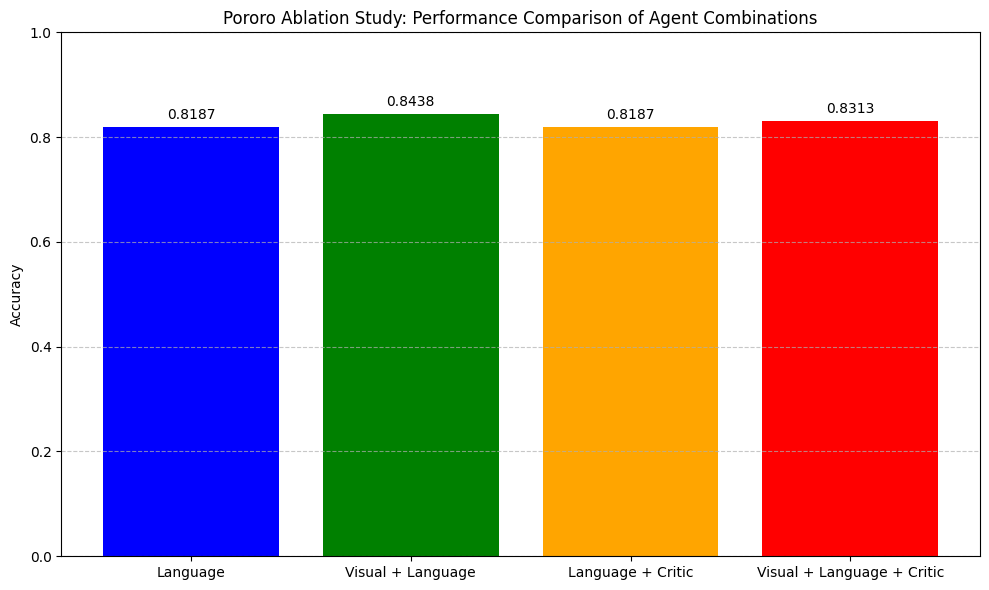

Comparison data saved to: results/analysis/pororo_comparison_20251110_221530.csv


In [ ]:
# Create visualization of ablation results
# Check if we only have visual configuration (no ablation comparison needed)
print(f"Available configurations: {list(all_results.keys())}")

# Check if only visual configuration exists
visual_only_config = (list(all_results.keys()) == ['visual'])
print(f"visual_only_config: {visual_only_config}")

if visual_only_config:
    print("Visual-only configuration detected. Skipping ablation comparison visualization.")
    print("Visual analysis results have been saved to the analysis directory.")
else:
    print("Multiple configurations or non-visual configuration detected. Proceeding with comparison visualization...")
    # Check if all_accuracies has values from current experiments
    if not all_accuracies:
        print("No accuracy results from current experiments.")
        print("Please run the ablation study experiments first before generating visualization.")

    # Use current experiment results if available
    # Safely access global accuracies variable if it exists
    if 'accuracies' in globals():
        local_accuracies = globals()['accuracies'] if globals()['accuracies'] else []
    else:
        local_accuracies = []

    if not all_accuracies and local_accuracies:
        # Use current experiment results if available
        avg_accuracy = np.mean(local_accuracies) if local_accuracies else 0
        config_name = ''
        if ENABLE_VISUAL_AGENT:
            config_name += 'visual_'
        if ENABLE_LANGUAGE_AGENT:
            config_name += 'language'
        if ENABLE_CRITIC_AGENT:
            config_name += '_critic'
        
        if config_name:
            all_accuracies[config_name] = avg_accuracy
            print(f"Using current experiment accuracy for {config_name}: {avg_accuracy:.4f}")

    # Only proceed with visualization if we have results
    if all_accuracies:
        # Create results dictionary for visualization
        results = {
            "Language": all_accuracies.get('language', 0),
            "Visual + Language": all_accuracies.get('visual_language', 0),
            "Language + Critic": all_accuracies.get('language_critic', 0),
            "Visual + Language + Critic": all_accuracies.get('visual_language_critic', 0)
        }

        # Print values for visualization
        print("\nAccuracy values for visualization:")
        for config, accuracy in results.items():
            print(f"{config}: {accuracy:.4f}")

        # Create folder to save figures if it doesn't exist
        os.makedirs("saved_figures", exist_ok=True)

        # Generate unique figure name with timestamp
        timestamp = time.strftime("%Y%m%d_%H%M%S")

        # Create visualization
        plt.figure(figsize=(10, 6))
        # Use distinct colors for different configurations
        bars = plt.bar(results.keys(), results.values(), color=['blue', 'green', 'orange', 'red'])
        plt.ylim(0, 1.0)
        plt.ylabel('Accuracy')
        plt.title('Pororo Ablation Study: Performance Comparison of Agent Combinations')

        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.4f}', ha='center', va='bottom')

        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()

        # Save figure with unique name
        plt.savefig(f"saved_figures/pororo_comparison_{timestamp}.png", dpi=300)
        print(f"Visualization saved to: saved_figures/pororo_comparison_{timestamp}.png")

        plt.show()

        # Save comparison results to CSV
        comparison_df = pd.DataFrame([
            {'Configuration': config, 'Accuracy': accuracy}
            for config, accuracy in results.items()
        ])

        comparison_path = f"results/comparison/pororo_comparison_{timestamp}.csv"
        os.makedirs("results/comparison", exist_ok=True)
        comparison_df.to_csv(comparison_path, index=False)
        print(f"Comparison data saved to: {comparison_path}")
    else:
        print("No ablation study results available for visualization.")